In [139]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [140]:
df = pd.read_csv("Data/tech_job_market_2019_2026.csv")

In [141]:
df.shape

(115000, 28)

### There are 115000 rows and 28 cols

In [142]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


### There are 21 object type cols, 3 integer type cols, 4 float type cols

In [144]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [145]:
print(df.columns.tolist())

['job_id', 'company_name', 'company_type', 'sector', 'company_size_employees', 'hq_country', 'job_role', 'seniority_level', 'years_experience_min', 'years_experience_max', 'required_tech_stack', 'primary_programming_language', 'work_mode', 'visa_sponsorship_offered', 'job_location_country', 'job_location_city', 'salary_currency', 'posting_date', 'application_deadline', 'date_position_filled', 'position_status', 'number_of_applicants', 'number_of_interview_rounds', 'offers_extended', 'offers_accepted', 'salary_min_usd', 'salary_max_usd', 'layoff_within_12_months_flag']


In [146]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [147]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
company_size_employees,115000.0,105386.103122,102117.290040,10.0,6038.75,88364.0,169840.25,488674.0
years_experience_min,115000.0,3.004452,3.093383,0.0,1.00,2.0,5.00,24.0
years_experience_max,115000.0,6.665443,5.073654,0.0,3.00,6.0,9.00,24.0
number_of_applicants,113890.0,181.659215,436.344753,-5.0,62.00,119.0,213.00,36816.0
number_of_interview_rounds,114564.0,3.307653,1.418283,1.0,2.00,3.0,4.00,8.0
offers_extended,114670.0,1.349786,1.457267,0.0,1.00,1.0,1.00,8.0
offers_accepted,114670.0,1.196634,1.122837,0.0,1.00,1.0,1.00,10.0


In [148]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

In [149]:
df.isnull().sum().sort_values(ascending=False).head(15)

date_position_filled            25781
job_location_city               25107
primary_programming_language    22475
application_deadline             5757
salary_max_usd                   3318
salary_min_usd                   3318
number_of_applicants             1110
number_of_interview_rounds        436
offers_accepted                   330
offers_extended                   330
company_type                        0
job_id                              0
required_tech_stack                 0
years_experience_max                0
years_experience_min                0
dtype: int64

### The highest missing values are found in date_position_filled,job_location_city,primary_programming_language

In [150]:
df.duplicated().sum()

np.int64(1193)

### There are 1193 duplicate rows. We have to remove them.

In [151]:
df = df.drop_duplicates()

In [152]:
df.duplicated().sum()

np.int64(0)

### Now there are 0 duplicate rows

In [153]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [154]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
company_size_employees,113807.0,105407.621552,102128.678701,10.0,6044.5,88378.0,169835.5,488674.0
years_experience_min,113807.0,3.004174,3.092817,0.0,1.0,2.0,5.0,24.0
years_experience_max,113807.0,6.664124,5.072197,0.0,3.0,6.0,9.0,24.0
number_of_applicants,112704.0,181.779112,437.798085,-5.0,62.0,119.0,213.0,36816.0
number_of_interview_rounds,113373.0,3.307525,1.418054,1.0,2.0,3.0,4.0,8.0
offers_extended,113479.0,1.349298,1.456431,0.0,1.0,1.0,1.0,8.0
offers_accepted,113479.0,1.196415,1.122430,0.0,1.0,1.0,1.0,10.0


### the value of mean > median so thereis positive skewness .

In [155]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['job_id', 'company_name', 'company_type', 'sector', 'hq_country',
       'job_role', 'seniority_level', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'salary_min_usd', 'salary_max_usd',
       'layoff_within_12_months_flag'],
      dtype='str')


C:\Users\vartika singh\AppData\Local\Temp\ipykernel_5772\4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


### Categorical Consistency

In [156]:
df['company_type'].value_counts(dropna=False)

company_type
MNC           55501
Mid-size      20079
Unicorn       15921
FAANG-tier    15783
Startup        6523
Name: count, dtype: int64

#### The company_type column contains five distinct categories: MNC, Mid-size, Unicorn, FAANG-tier, and Startup. No missing values or obvious spelling and casing inconsistencies were observed.

In [157]:
df['sector'].value_counts(dropna=False)

sector
E-commerce       16491
HealthTech       15125
Fintech          13008
EdTech           11414
Social/AdTech     8938
AI/ML             8803
SaaS              8522
Crypto/Web3       7954
Cloud/Infra       6502
Cybersecurity     5677
Logistics         5231
Gaming            4985
e-commerce         172
healthtech         145
fintech            139
edtech             125
social/adtech       99
saas                88
crypto/web3         87
ai/ml               87
cloud/infra         60
gaming              57
logistics           49
cybersecurity       49
Name: count, dtype: int64

### casing inconsistencies were observed.

In [158]:
df['sector']=df['sector'].str.strip().str.lower()

In [159]:
df['sector'].value_counts(dropna=False)

sector
e-commerce       16663
healthtech       15270
fintech          13147
edtech           11539
social/adtech     9037
ai/ml             8890
saas              8610
crypto/web3       8041
cloud/infra       6562
cybersecurity     5726
logistics         5280
gaming            5042
Name: count, dtype: int64

In [160]:
df['hq_country'].value_counts(dropna=False)

hq_country
USA            35356
India          18763
UK             15411
Germany         7108
Canada          6179
Brazil          5890
Singapore       5765
France          5050
Australia       3423
UAE             3158
Israel          3012
Netherlands     2613
Ireland         2079
Name: count, dtype: int64

In [161]:
df['job_role'].value_counts(dropna=False)

job_role
Backend Engineer             5939
Embedded Systems Engineer    5912
QA Engineer                  5854
Software Engineer            5820
Frontend Engineer            5786
                             ... 
 QA Engineer                    1
 FRONTEND ENGINEER              1
 Data Analyst                   1
 Mobile Engineer (iOS)          1
 DATA ENGINEER                  1
Name: count, Length: 160, dtype: int64

### inconsistencies are observed

In [162]:
df['job_role']=df['job_role'].str.strip().str.lower()

In [163]:
df['job_role'].value_counts(dropna=False)

job_role
backend engineer                 6095
embedded systems engineer        6069
qa engineer                      6005
software engineer                5960
frontend engineer                5950
mobile engineer (ios)            5901
mobile engineer (android)        5855
full stack engineer              5847
devops engineer                  3676
infrastructure engineer          3642
cloud engineer                   3607
platform engineer                3593
site reliability engineer        3590
machine learning engineer        3172
data analyst                     3137
analytics engineer               2993
data scientist                   2987
research scientist               2963
data engineer                    2945
product owner                    2912
product manager                  2910
associate product manager        2878
technical program manager        2874
soc analyst                      2325
security engineer                2311
penetration tester               2310
app

In [164]:
df['seniority_level'].value_counts(dropna=False)

seniority_level
Mid          38686
Entry        28322
Senior       22776
Lead         10366
Intern        9157
Principal     4500
Name: count, dtype: int64

In [165]:
df['required_tech_stack'].value_counts(dropna=False).head(20)

required_tech_stack
Sketch, Framer        274
Adobe XD, Framer      252
Figma, Framer         251
Adobe XD, Figma       248
Figma, Adobe XD       247
Sketch, Adobe XD      243
Framer, Sketch        237
Framer, Figma         233
Sketch, Figma         229
Figma, Sketch         225
Adobe XD, Sketch      223
Framer, Adobe XD      201
C++, React            189
TypeScript, Swift     188
C++, TypeScript       187
C++, Go               187
C++, Python           182
TypeScript, Kotlin    182
React, Node.js        182
Swift, Python         181
Name: count, dtype: int64

In [166]:
df['primary_programming_language'].value_counts(dropna=False)

primary_programming_language
NaN           22263
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
Unknown         548
TBD             530
Name: count, dtype: int64

In [167]:
df['work_mode'].value_counts(dropna=False)

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64

### short forms are  used which are causing inconsistencies 

In [168]:
df['work_mode'] = df['work_mode'].str.strip().str.lower()

df['work_mode'] = df['work_mode'].replace(
    {
    'wfh': 'remote',
    'work from home': 'remote',
    'on-site': 'onsite'
    })

In [169]:
df['work_mode'].value_counts(dropna=False)

work_mode
hybrid       51243
remote       34243
onsite       27860
in-office      461
Name: count, dtype: int64

In [170]:
df['visa_sponsorship_offered'].value_counts(dropna=False)

visa_sponsorship_offered
0        19625
False    19555
N        19553
No       19346
Yes       9001
True      8937
1         8897
Y         8893
Name: count, dtype: int64

### diff representations are used for yes/no

In [171]:
df['visa_sponsorship_offered'] = df['visa_sponsorship_offered'].replace(
    {
    '0': 'No',
    'False': 'No',
    'N': 'No',
    'No': 'No',
    'Yes': 'Yes',
    'True': 'Yes',
    '1': 'Yes',
    'Y': 'Yes'
})

In [172]:
df['visa_sponsorship_offered'].value_counts(dropna=False)

visa_sponsorship_offered
No     78079
Yes    35728
Name: count, dtype: int64

In [173]:
df['position_status'].value_counts(dropna=False)

position_status
Filled       90118
Open         10051
Cancelled     7970
Withdrawn     5668
Name: count, dtype: int64

In [174]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [175]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['job_id', 'company_name', 'company_type', 'sector', 'hq_country',
       'job_role', 'seniority_level', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'salary_min_usd', 'salary_max_usd',
       'layoff_within_12_months_flag'],
      dtype='str')


C:\Users\vartika singh\AppData\Local\Temp\ipykernel_5772\4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [176]:
df['salary_currency'].value_counts(dropna=False)

salary_currency
USD    35895
INR    19426
EUR    16901
GBP    14477
CAD     6240
SGD     5718
BRL     5304
AUD     3549
ILS     3268
AED     3029
Name: count, dtype: int64

In [177]:
df['posting_date'].value_counts(dropna=False)

posting_date
2026-01-04    96
2026-02-16    95
2026-02-06    94
2024-02-15    92
2025-06-13    91
              ..
2022-07-29     1
2024-03-31     1
2025-11-29     1
2025-06-30     1
2026-01-29     1
Name: count, Length: 2638, dtype: int64

In [178]:
df['application_deadline'].describe()

count                108112
unique                 2843
top       Open Until Filled
freq                   2799
Name: application_deadline, dtype: object

### The application_deadline coloumns contains 2843 unique  values,with "open until filled "being most frequent category.This means this col contains both deadline info and non date textual values. 

In [179]:
df['date_position_filled'].value_counts(dropna=False)

date_position_filled
NaN           25514
2026-09-03     1269
2026-06-04       71
2025-11-18       71
2026-03-20       71
              ...  
2019-01-14        1
2019-01-20        1
2019-01-03        1
2019-01-18        1
2019-01-05        1
Name: count, Length: 2792, dtype: int64

In [180]:
df['position_status'].value_counts(dropna=False)

position_status
Filled       90118
Open         10051
Cancelled     7970
Withdrawn     5668
Name: count, dtype: int64

In [181]:
df['layoff_within_12_months_flag'].value_counts(dropna=False)

layoff_within_12_months_flag
N        24905
0        24736
False    24717
No       24526
Y         3785
Yes       3759
1         3734
True      3645
Name: count, dtype: int64

### diff representation of yes/no is used causing inconsistencies

In [182]:
df['layoff_within_12_months_flag'] = df['layoff_within_12_months_flag'].replace(
    {
    'N': 'No',
    '0': 'No',
    'False': 'No',
    'Y': 'Yes',
    '1': 'Yes',
    'True': 'Yes'
})

In [183]:
df['layoff_within_12_months_flag'].value_counts(dropna=False)

layoff_within_12_months_flag
No     98884
Yes    14923
Name: count, dtype: int64

In [184]:
df['job_id'].value_counts(dropna=False)

job_id
JOB079459    2
JOB078958    2
JOB015271    2
JOB063315    2
JOB078694    2
            ..
JOB012896    1
JOB060961    1
JOB006013    1
JOB063108    1
JOB006559    1
Name: count, Length: 113000, dtype: int64

In [185]:
df['company_name'].value_counts(dropna=False)

company_name
NexusShield            3228
MeridianToken          3173
RidgeFreight Labs      3084
SpireCloud             3000
AetherAI Co            2720
                       ... 
AETHERCOGNITION           1
  MeridianReach Inc       1
NovaArcade Co             1
  SpireHub Inc            1
CATALYSTCONNECT CO        1
Name: count, Length: 898, dtype: int64

In [186]:
df['salary_min_usd'].describe()

count     110527
unique      4795
top           -1
freq         727
Name: salary_min_usd, dtype: object

### the salary_min_usd colomn contains 727 occurences of-1,which may represent invalid salary information. 

In [187]:
df['salary_max_usd'].value_counts().head(10)

salary_max_usd
-1               727
Not Disclosed    682
104900.0         102
93400.0          102
107000.0         102
118000.0          99
122700.0          94
111500.0          94
112000.0          94
114900.0          94
Name: count, dtype: int64

The salary_max_usd column contains both numerical salary values and non-numeric placeholders such as -1 and "Not Disclosed". These invalid or unavailable salary values need to be handled before converting the column to a numeric datatype and performing further analysis.

### Logical AND Referential checks

In [188]:
(df['salary_min_usd'] > df['salary_max_usd']).sum()

np.int64(16772)

The logical consistency check identified 16,772 records where the minimum salary is greater than max salary

In [189]:
print(df.columns.tolist())

['job_id', 'company_name', 'company_type', 'sector', 'company_size_employees', 'hq_country', 'job_role', 'seniority_level', 'years_experience_min', 'years_experience_max', 'required_tech_stack', 'primary_programming_language', 'work_mode', 'visa_sponsorship_offered', 'job_location_country', 'job_location_city', 'salary_currency', 'posting_date', 'application_deadline', 'date_position_filled', 'position_status', 'number_of_applicants', 'number_of_interview_rounds', 'offers_extended', 'offers_accepted', 'salary_min_usd', 'salary_max_usd', 'layoff_within_12_months_flag']


In [190]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [191]:
(df['years_experience_min'] > df['years_experience_max']).sum()

np.int64(315)

The logical consistency check identified 315 records where the min year experience is greater than max year experience

In [192]:
(df['offers_accepted'] > df['offers_extended']).sum()

np.int64(591)

The logical consistency check identified 591 records where the offer accepted is greater than offer extended

In [193]:
(df['application_deadline'] < df['posting_date']).sum()

np.int64(0)

In [194]:
(df['date_position_filled'] < df['posting_date']).sum()

np.int64(439)

The logical consistency check identified 439 records where the posting date is given before date position filled 

In [195]:
(df['number_of_interview_rounds'] < 0).sum()

np.int64(0)

In [196]:
(df['number_of_applicants'] < 0).sum()

np.int64(243)

there are 243 negative number of applicants which generally cause problem in further analysis

In [197]:
((df['offers_extended'] < 0) | (df['offers_accepted'] < 0)).sum()

np.int64(0)

In [198]:
((df['years_experience_min'] < 0) | (df['years_experience_max'] < 0)).sum()

np.int64(0)

 Overall, the logical and referential checks revealed several logical inconsistencies in the dataset, including invalid salary ranges, experience ranges, offer counts, position-filled dates, and negative applicant values. However, application deadlines and interview rounds were found to be logically consistent. These issues should be considered before further analysis and interpretation.

### Numerical Distribution and outliers 

In [199]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted'],
      dtype='str')


In [200]:
df[numerical_cols].describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [201]:
df[['salary_min_usd', 'salary_max_usd']].dtypes

salary_min_usd    str
salary_max_usd    str
dtype: object

In [202]:
df.head(10)

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,No
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,No
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,Yes
5,JOB099770,QuantumBuzz Technologies,MNC,saas,86535,UK,data engineer,Intern,1,1,...,2025-09-09 00:00:00,2025-09-09,Filled,58.0,2.0,1.0,1.0,33100.0,38500.0,No
6,JOB080320,SpireCloud,MNC,fintech,369939,USA,ui designer,Entry,0,1,...,2022-06-16 00:00:00,2022-06-09,Filled,281.0,1.0,1.0,3.0,87400.0,98100.0,No
7,JOB057551,EchoCortex Co,MNC,cybersecurity,128882,USA,embedded systems engineer,Entry,0,4,...,2024-05-25 00:00:00,2024-05-29,Filled,258.0,3.0,1.0,1.0,131100.0,103900.0,No
8,JOB019108,NimbusFlow,FAANG-tier,crypto/web3,53256,UK,product designer,Mid,1,5,...,2022-04-21 00:00:00,2022-08-17,Filled,78.0,4.0,1.0,1.0,114500.0,139700.0,No
9,JOB088302,VantageChain Systems,Startup,ai/ml,380,Brazil,product designer,Intern,0,0,...,2025-05-23 00:00:00,2025-05-05,Filled,349.0,3.0,1.0,1.0,42500.0,47600.0,No


In [203]:
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'], errors='coerce')

### Salary is of str type and we have converted it to numerical type and the non numeric values are converted to nan values

In [204]:
df[['salary_min_usd', 'salary_max_usd']].dtypes

salary_min_usd    float64
salary_max_usd    float64
dtype: object

In [205]:
numerical_cols = df.select_dtypes(include=['number']).columns
print(numerical_cols)

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted',
       'salary_min_usd', 'salary_max_usd'],
      dtype='str')


In [206]:
df[numerical_cols].describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000,108475.000000,1.098450e+05
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415,114655.157898,1.417029e+05
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430,57581.883453,9.163979e+04
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000,-1.000000,-1.000000e+00
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000,75900.000000,9.190000e+04
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000,105400.000000,1.281000e+05
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000,145800.000000,1.774000e+05
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000,531800.000000,3.552000e+06


In [207]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1.0,-1.0,No
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,No
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,NaN,245400.0,Yes


### missing values treat

In [208]:
df.isnull().sum().sort_values(ascending=False).head(25)

date_position_filled            25514
job_location_city               24847
primary_programming_language    22263
application_deadline             5695
salary_min_usd                   5332
salary_max_usd                   3962
number_of_applicants             1103
number_of_interview_rounds        434
offers_accepted                   328
offers_extended                   328
company_type                        0
job_id                              0
required_tech_stack                 0
years_experience_max                0
years_experience_min                0
seniority_level                     0
hq_country                          0
job_role                            0
company_size_employees              0
sector                              0
company_name                        0
salary_currency                     0
visa_sponsorship_offered            0
job_location_country                0
work_mode                           0
dtype: int64

In [209]:
df['job_location_city'].value_counts(dropna=False)

job_location_city
NaN               24847
Singapore          4469
Austin             4057
New York           4047
Denver             4010
San Francisco      3984
Seattle            3975
Chicago            3972
Boston             3918
London             2840
Manchester         2821
Cambridge          2816
Edinburgh          2813
Hyderabad          2205
Chennai            2196
Noida              2192
Bangalore          2186
Pune               2184
Gurugram           2158
Mumbai             2110
Sao Paulo          2082
Rio de Janeiro     2059
Lyon               1877
Paris              1861
Dublin             1660
Frankfurt          1414
Munich             1406
Hamburg            1390
Sydney             1378
Herzliya           1353
Melbourne          1339
Berlin             1336
Tel Aviv           1221
Toronto            1216
Montreal           1215
Abu Dhabi          1202
Vancouver          1194
Waterloo           1192
Dubai              1159
Amsterdam          1155
Eindhoven          115

In [210]:
df[df['job_location_city'].isnull()].head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
8,JOB019108,NimbusFlow,FAANG-tier,crypto/web3,53256,UK,product designer,Mid,1,5,...,2022-04-21 00:00:00,2022-08-17,Filled,78.0,4.0,1.0,1.0,114500.0,139700.0,No
12,JOB109216,MeridianToken,MNC,edtech,254721,USA,mobile engineer (ios),Senior,6,8,...,2022-11-26 00:00:00,2022-12-11,Filled,114.0,3.0,1.0,1.0,126200.0,144300.0,Yes
16,JOB077076,PinnacleBlock,MNC,e-commerce,102403,Singapore,software engineer,Lead,7,16,...,2025-11-14 00:00:00,2025-12-03,Filled,69.0,5.0,3.0,2.0,130900.0,172500.0,No
19,JOB101088,EchoCortex Co,MNC,cybersecurity,102354,USA,soc analyst,Lead,7,14,...,2024-04-19 00:00:00,2024-05-17,Filled,39.0,6.0,5.0,4.0,174800.0,189900.0,No


In [211]:
df.loc[df['job_location_city'].isnull(),'job_location_country'].value_counts()

job_location_country
USA            7885
India          4173
UK             3171
Germany        1540
Canada         1418
Singapore      1242
Brazil         1151
France         1019
Australia       828
Israel          693
UAE             664
Netherlands     602
Ireland         461
Name: count, dtype: int64

The job_location_city column had 24847 missing values.<br>
After checking the corresponding countries ,found that missing values are for multiple countries<br>

In [212]:
df['job_location_city'] = df['job_location_city'].fillna('Unknown')

I filled the missing values with "unknown" so that false data will not form

In [213]:
df[df['job_location_city'].isnull()].head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag


In [214]:
df['primary_programming_language'].value_counts(dropna=False)

primary_programming_language
NaN           22263
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
Unknown         548
TBD             530
Name: count, dtype: int64

In [215]:
df['primary_programming_language'] = df['primary_programming_language'].fillna('Unknown')

The primary_programming language coloumn had 22263 missing values which was large part of dataset.<br>
Although python and c++ are  most frequent language but if we fill all values with one of these it will be incorrect bcoz this was a significant potion of dataset.<br>
So i replaced the missing values with 'unknown' without making false assumptions



In [216]:
df['primary_programming_language'].value_counts(dropna=False)

primary_programming_language
Unknown       22811
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
TBD             530
Name: count, dtype: int64

In [217]:
df[df['application_deadline'].isnull()].head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
11,JOB095723,EchoVita Technologies,Startup,ai/ml,160,India,platform engineer,Mid,2,7,...,NaN,2021-08-09,Filled,41.0,3.0,1.0,1.0,115800.0,152400.0,No
51,JOB007437,DriftGame,Unicorn,healthtech,11873,India,soc analyst,Entry,1,2,...,NaN,2026-08-07,Filled,107.0,3.0,1.0,1.0,66000.0,74600.0,No
73,JOB105747,AnchorBuzz Labs,MNC,healthtech,224413,USA,site reliability engineer,Entry,0,2,...,NaN,NaN,Open,150.0,1.0,2.0,2.0,68800.0,76000.0,No
85,JOB069629,ZenithReach Systems,Mid-size,logistics,2375,India,qa engineer,Entry,0,3,...,NaN,NaN,Open,118.0,2.0,1.0,1.0,58300.0,66300.0,Yes
118,JOB073008,AstraCognition,Unicorn,healthtech,15236,Netherlands,cloud engineer,Senior,6,9,...,NaN,2025-05-05,Filled,90.0,3.0,1.0,1.0,159800.0,214800.0,No


In [218]:
df['application_deadline'].isnull().sum()

np.int64(5695)

In [219]:
df['application_deadline'].value_counts(dropna=False)

application_deadline
NaN                    5695
Open Until Filled      2799
Rolling                2781
2026-04-02 00:00:00      80
2026-03-24 00:00:00      79
                       ... 
2026-10-25 00:00:00       4
2019-01-20 00:00:00       4
2019-01-18 00:00:00       4
2019-01-16 00:00:00       3
2019-01-17 00:00:00       1
Name: count, Length: 2844, dtype: int64

In [220]:
df['application_deadline'] = df['application_deadline'].fillna('Not Specified')

There are three types of values in application_deadline coloumn-open until filled,rolling,dates.<br>
There are 5695 missing values <br>
I have replaced these missing values with not specified

In [221]:
df['application_deadline'].value_counts(dropna=False)

application_deadline
Not Specified          5695
Open Until Filled      2799
Rolling                2781
2026-04-02 00:00:00      80
2026-03-24 00:00:00      79
                       ... 
2026-10-25 00:00:00       4
2019-01-20 00:00:00       4
2019-01-18 00:00:00       4
2019-01-16 00:00:00       3
2019-01-17 00:00:00       1
Name: count, Length: 2844, dtype: int64

In [222]:
df[df['number_of_applicants'].isnull()].head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
86,JOB102721,MeridianToken,MNC,edtech,272193,USA,full stack engineer,Mid,3,5,...,2019-06-22 00:00:00,NaN,Cancelled,NaN,4.0,1.0,1.0,105900.0,118100.0,No
107,JOB079271,NovaFleet,FAANG-tier,e-commerce,147238,Canada,infrastructure engineer,Senior,5,10,...,2025-12-15 00:00:00,2025-12-19,Filled,NaN,5.0,1.0,1.0,186100.0,213300.0,No
211,JOB000172,NimbusFlow,FAANG-tier,crypto/web3,72699,UK,software engineer,Entry,0,1,...,2025-10-29 00:00:00,2025-12-11,Filled,NaN,3.0,1.0,1.0,112800.0,145000.0,No
226,JOB091879,QuantumReach Co,Mid-size,cloud/infra,3835,USA,product manager,Mid,1,4,...,2021-04-02 00:00:00,2021-03-23,Filled,NaN,2.0,1.0,1.0,102100.0,111300.0,No
400,JOB106556,TideSentinel Technologies,Unicorn,healthtech,12615,UK,frontend engineer,Mid,1,5,...,2026-03-21 00:00:00,2026-02-24,Filled,NaN,2.0,1.0,1.0,135800.0,174700.0,No


In [223]:
df['number_of_applicants'].describe()

count    112704.000000
mean        181.779112
std         437.798085
min          -5.000000
25%          62.000000
50%         119.000000
75%         213.000000
max       36816.000000
Name: number_of_applicants, dtype: float64

In [224]:
df.loc[df['number_of_applicants'] < 0, 'number_of_applicants'] = np.nan

I have done this because no of applicants can never be negative.Therefore ,all the negative value are invalid and converted to NaN 

In [225]:
df['number_of_applicants'].isnull().sum()

np.int64(1346)

In [226]:
df['number_of_applicants'] = df['number_of_applicants'].fillna(df['number_of_applicants'].median())

I have used median because the coloumn contains highly varying values and outliers like the max no of applicants are 36816 whic is very high.
Mean is not used because it will be more affected by outliers than median

In [227]:
df['number_of_applicants'].isnull().sum()

np.int64(0)

In [228]:
df['number_of_interview_rounds'].isnull().sum()

np.int64(434)

In [229]:
df['number_of_interview_rounds'].describe()

count    113373.000000
mean          3.307525
std           1.418054
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           8.000000
Name: number_of_interview_rounds, dtype: float64

In [230]:
df['number_of_interview_rounds'] = df['number_of_interview_rounds'].fillna( df['number_of_interview_rounds'].median())

In [231]:
df['number_of_interview_rounds'].isnull().sum()

np.int64(0)

Here we can use both mean and median becuase both are close to 3 but we see that mean is a decimal value and median is a whole number.
So to avoid decimal value  i have used median

In [232]:
df['offers_extended'].isnull().sum()

np.int64(328)

In [233]:
df['offers_extended'].describe()

count    113479.000000
mean          1.349298
std           1.456431
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           8.000000
Name: offers_extended, dtype: float64

In [234]:
df['offers_extended'] = df['offers_extended'].fillna(df['offers_extended'].median())

In [235]:
df['offers_extended'].isnull().sum()

np.int64(0)

In [236]:
df['offers_accepted'].isnull().sum()

np.int64(328)

In [237]:
df['offers_accepted'].describe()

count    113479.000000
mean          1.196415
std           1.122430
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          10.000000
Name: offers_accepted, dtype: float64

In [238]:
df['offers_accepted'] = df['offers_accepted'].fillna(df['offers_accepted'].median())

In [239]:
df['offers_accepted'].isnull().sum()

np.int64(0)

In [240]:
df['salary_min_usd'].isnull().sum()

np.int64(5332)

In [241]:
df['salary_min_usd'].describe()

count    108475.000000
mean     114655.157898
std       57581.883453
min          -1.000000
25%       75900.000000
50%      105400.000000
75%      145800.000000
max      531800.000000
Name: salary_min_usd, dtype: float64

In [242]:
(df['salary_min_usd']==-1).sum()

np.int64(727)

In [243]:
df['salary_min_usd'] = df['salary_min_usd'].replace(-1, np.nan)

In [244]:
df['salary_min_usd'].isnull().sum()

np.int64(6059)

In [245]:
df['salary_min_usd'] = df['salary_min_usd'].fillna(df['salary_min_usd'].median())

In [246]:
df['salary_min_usd'].isnull().sum()

np.int64(0)

Median was used because salary data contains extreme outliers, and the median is less affected by them than the mean.

In [247]:
df['salary_max_usd'].isnull().sum()

np.int64(3962)

In [248]:
df['salary_max_usd'].describe()

count    1.098450e+05
mean     1.417029e+05
std      9.163979e+04
min     -1.000000e+00
25%      9.190000e+04
50%      1.281000e+05
75%      1.774000e+05
max      3.552000e+06
Name: salary_max_usd, dtype: float64

In [249]:
df.loc[df['salary_max_usd'] == -1, 'salary_max_usd'] = np.nan

In [250]:
df['salary_max_usd'].isnull().sum()

np.int64(4689)

In [251]:
df['salary_max_usd'] = df['salary_max_usd'].fillna(df['salary_max_usd'].median())

Median was used because salary data may contain extreme values, and the median is less affected by outliers than the mean.

In [252]:
df['salary_max_usd'].isnull().sum()

np.int64(0)

In [253]:
df['date_position_filled'].isnull().sum()

np.int64(25514)

In [254]:
df['date_position_filled'].dtype

<StringDtype(na_value=nan)>

In [255]:
df['date_position_filled'] = pd.to_datetime(df['date_position_filled'],errors='coerce')

In [256]:
df['date_position_filled'].dtype

dtype('<M8[us]')

In [257]:
df.isnull().sum().sum()

np.int64(25514)

In [258]:
df['salary_min_usd'].skew()

np.float64(1.0145328653628707)

this col is positively skewed

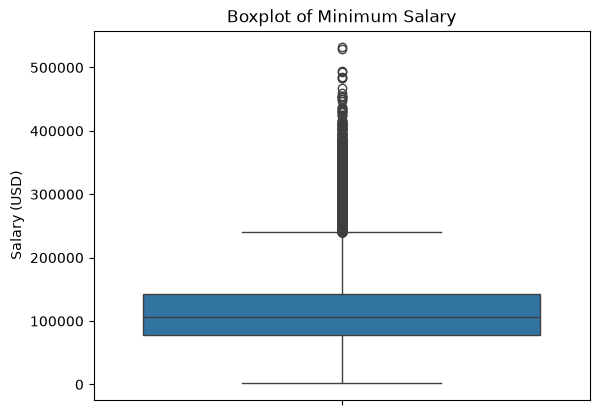

In [259]:
sns.boxplot(y=df['salary_min_usd'])
plt.title('Boxplot of Minimum Salary')
plt.ylabel('Salary (USD)')
plt.show()

The minimum salary data contains several high-value outliers.<br>
Most salaries are concentrated around 70,000–140,000.<br>
A small number of job postings have unusually high minimum salaries, reaching above 500,000.<br>
The middle line represents the median approximately 120000<br>
The dots here represents the outliers<br>
This is right -skewd

In [260]:
percentile25=df['salary_min_usd'].quantile(0.25)
percentile25

np.float64(78300.0)

In [261]:
percentile75=df['salary_min_usd'].quantile(0.75)

In [262]:
iqr=percentile75-percentile25

In [263]:
iqr

np.float64(64900.0)

In [264]:
upper_limit=percentile75+1.5*iqr
lower_limit=percentile75-1.5*iqr

In [265]:
upper_limit


np.float64(240550.0)

In [266]:
lower_limit

np.float64(45850.0)

### univariate analysis

Univariate numerical-histogram,boxplot,density plot

In [267]:
df['salary_max_usd'].describe()

count    1.138070e+05
mean     1.420723e+05
std      8.935350e+04
min      1.590000e+04
25%      9.420000e+04
50%      1.287000e+05
75%      1.750000e+05
max      3.552000e+06
Name: salary_max_usd, dtype: float64

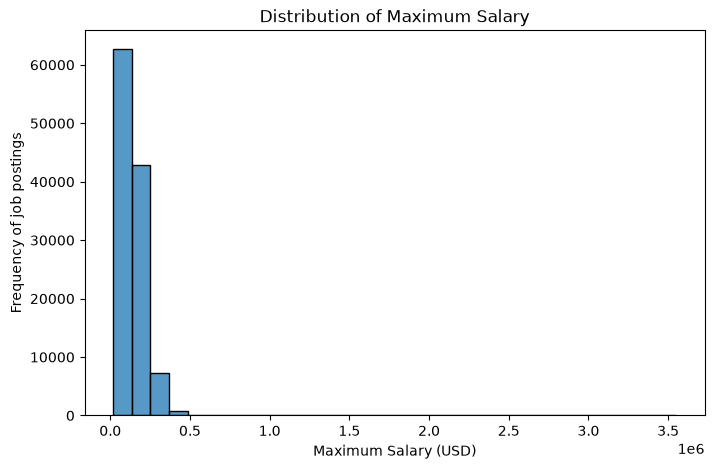

In [268]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_max_usd'], bins=30)
plt.title('Distribution of Maximum Salary')
plt.xlabel('Maximum Salary (USD)')
plt.ylabel('Frequency of job postings')

plt.show()

Most maximum salaries are concentrated at the lower end between 0.0-0.3.<br>
Therefore the data is right skewed <br>
A few extremely high salary values are likel potentially outliers

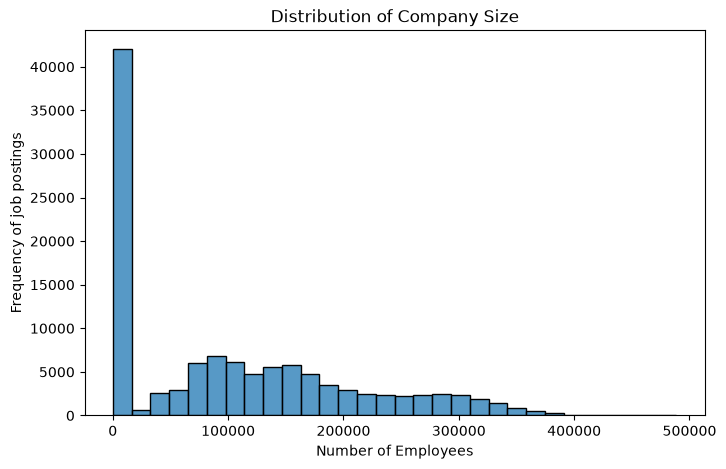

In [269]:
plt.figure(figsize=(8,5))
sns.histplot(df['company_size_employees'], bins=30)
plt.title('Distribution of Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Frequency of job postings')
plt.show()

Most of the company size values are concentrated near the lower end of the distribution<br>
As the no. of employes increases , frequncy of job postings  generally decreases.<br>
Comapany size distribution is right skewed

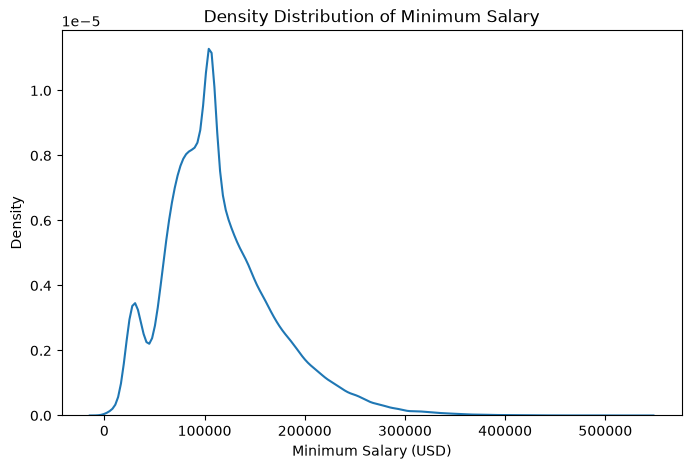

In [270]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df,x='salary_min_usd')
plt.title('Density Distribution of Minimum Salary')
plt.xlabel('Minimum Salary (USD)')
plt.ylabel('Density')

plt.show()

Most minimum salary values are concentrated in the lower salary range.<br>
Only a few jobs have very high minimum salaries,.
The distribution is right skewed .

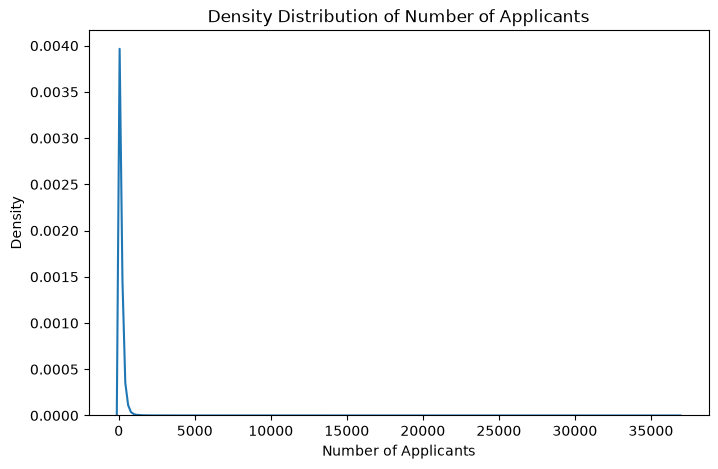

In [271]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=df, x='number_of_applicants')

plt.title('Density Distribution of Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('Density')

plt.show()

Most job postings have a relatively low number of applicants.<br>
The distribution is highly right-skewed.<br>
A few job postings have an extremely high number of applicants.<br>

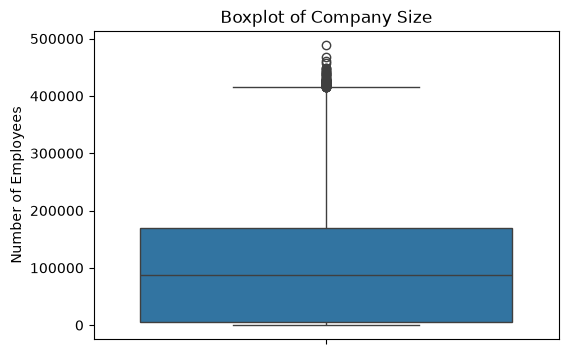

In [272]:
plt.figure(figsize=(6,4))
sns.boxplot(df['company_size_employees'].dropna())
plt.title('Boxplot of Company Size')
plt.ylabel('Number of Employees')
plt.show()

The median company size around 90,000.<br>
The upper whisker is much longer than lower one.<br>
The company size distribution is right-skewed.<br>
There are several high value outliers.


Univariate - categorical

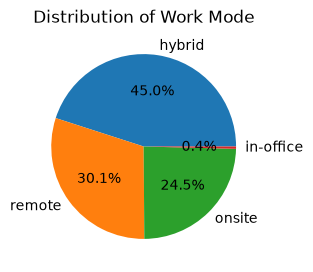

In [273]:
df['work_mode'].value_counts().plot(
    kind='pie',
    autopct='%0.1f%%',
    figsize=(3,3)
)
plt.title('Distribution of Work Mode')
plt.ylabel('')
plt.show()

Hybrid work mode is highly common having 45% job postings.<br>
Remote work is second most common at 30.1%<br>
onsite jobs have 24.5% job postings<br>
in-office work is extremely rare only 0.4% job postings are there

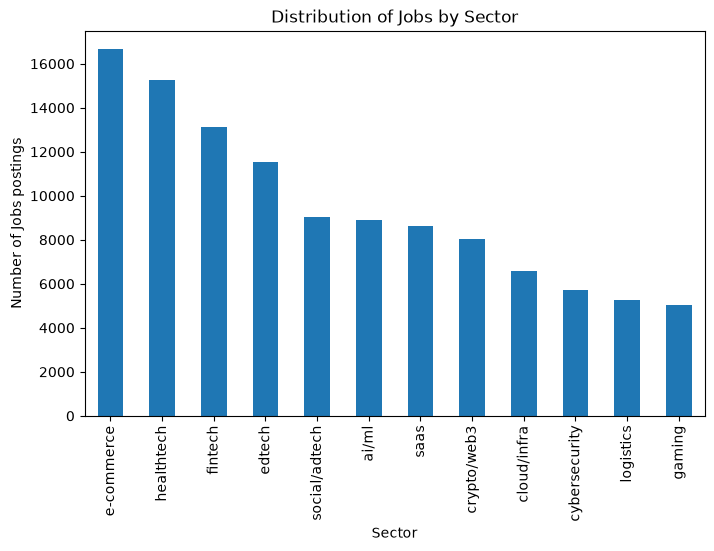

In [274]:
plt.figure(figsize=(8,5))
df['sector'].value_counts().plot(kind='bar')
plt.title('Distribution of Jobs by Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Jobs postings')

plt.show()

E-commerce has the highest number of job postings.<br>
Healthtech has the second-highest number of jobs.<br>
Fintech and Edtech also show a high number of job opportunities.<br>
Gaming has the lowest number of job postings.<br>
overall job opportunities are more concentrated in E-commerce, Healthtech, and Fintech sectors.

### HEATMAP FOR STANDING CORRELATION

<Axes: >

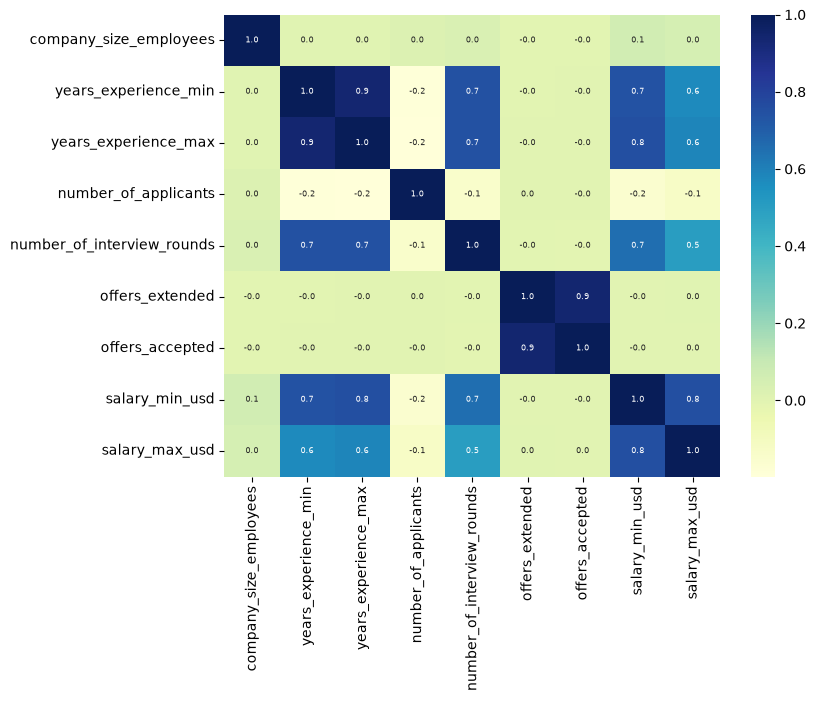

In [279]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True) , annot = True , fmt = '.1f' , cmap = 'YlGnBu' , annot_kws = {'size':6})

### By analyzing the heatmap we select the following column for Bivariate analysis
<br>
years_experience_min with salary_min_usd<br>
salary_min_usd with salary_max_usd<br>
offers_extended with offers_accepted <br>
years_experience_max with salary_min_usd<br>
years_experience_min with years_experience_max<br>


### Bivariate analysis

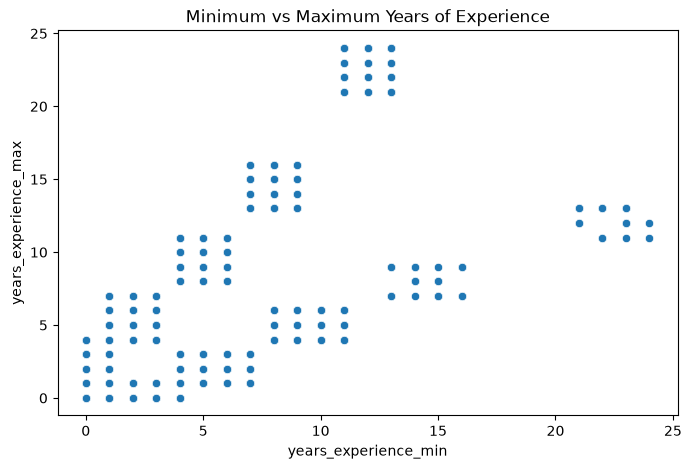

In [290]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='years_experience_min', y='years_experience_max')
plt.title('Minimum vs Maximum Years of Experience')
plt.show()

Each point here represents a job posting.<br>
The X-axis shows minimum experience and the Y-axis shows maximum experience.<br> 
The graph shows that different jobs have different experience requirements.


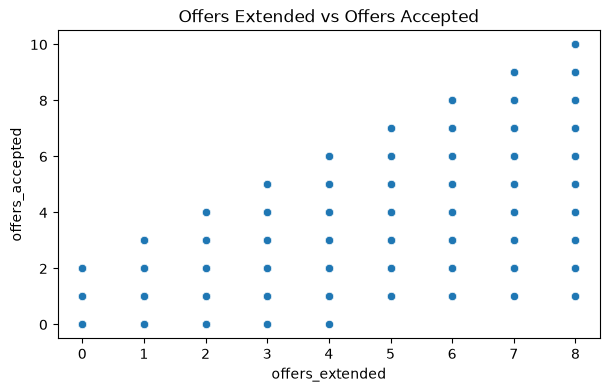

In [293]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x='offers_extended', y='offers_accepted')
plt.title('Offers Extended vs Offers Accepted')
plt.show()

AS number of offer_extended increase we see that number of offer_accepted also increase

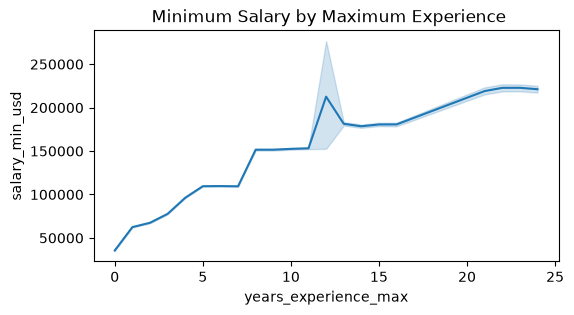

In [296]:
plt.figure(figsize=(6,3))
sns.lineplot(data=df,x='years_experience_max',y='salary_min_usd')
plt.title(' Minimum Salary by Maximum Experience')
plt.show()

Minimum salary generally increases with maximum experience.<br>
Some fluctuations can be seen in the trend.<br>
This shaded area shows the variation in values or uncertainity 

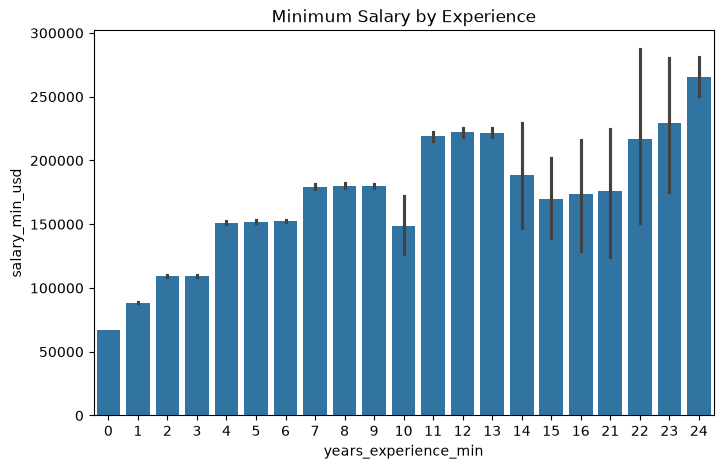

In [297]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='years_experience_min',y='salary_min_usd')
plt.title('Minimum Salary by Experience')
plt.show()

Minimum salary generally increases with experience.<br>
high experience levels provide high salaries<br>
but there are some exceptions like 10 year has less salary compared to 9 years exp<br>
Here there dark lines represent variations, long dark line represents more variations & the shorter one means less variations

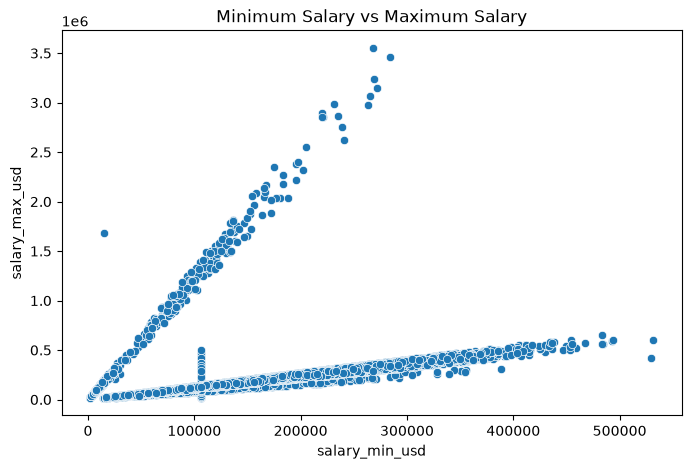

In [292]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='salary_min_usd',y='salary_max_usd')
plt.title('Minimum Salary vs Maximum Salary')
plt.show()

Generally when min salary increase, max salary also increases.<br>
The point which are far away from main pattern shows that they are outliers.<br>
That V shape pattern here shows that there are different salary patterns in a dataset.<br>
Some jobs have normal salary range, while others have max salary range than others .